# Diabetes Prediction: Comparative Feature-Set Study

**Research question:** How much predictive performance is lost when laboratory-based features
(HbA1c and blood glucose level) are unavailable?

Both Model A and Model B predict the **same binary target**: `diabetes` (0 = No, 1 = Yes).
The models are independent; this is **not a sequential clinical workflow**.

- **Model A – Reduced / Non-Laboratory:** gender, age, hypertension, heart_disease, smoking_history, bmi
- **Model B – Full / Laboratory-Informed:** all Model A features + HbA1c_level + blood_glucose_level

Algorithms compared:
- Random Forest
- K-Nearest Neighbors (KNN)

Methodological improvements based on tutor feedback:
- One-Hot Encoding for nominal categorical variables
- `bmi_category` removed because it is deterministically derived from BMI
- One fixed 70:30 stratified train/test split for all four experiments
- 5-fold Stratified Cross-Validation for hyperparameter tuning
- SMOTENC applied **inside cross-validation folds** and only to training data
- Accuracy, Precision, Recall, Positive-class F1, Macro F1, Specificity, and Confusion Matrix reported


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

os.makedirs("models", exist_ok=True)


## 1. Load Dataset


In [4]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print("Shape:", df.shape)
display(df.head())

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Preliminary Analysis (Before Preprocessing)


In [5]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget counts:")
print(df["diabetes"].value_counts())

print("\nTarget percentages:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

print("\nGender categories:")
print(df["gender"].value_counts())

print("\nSmoking-history categories:")
print(df["smoking_history"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Target 

The class distribution is examined **before preprocessing** because the identified imbalance
motivates the use of SMOTENC on the training data. The test set is never oversampled.


## 3. Define Feature Sets and Target


In [6]:
target_col = "diabetes"
categorical_features = ["gender", "smoking_history"]

model_a_numeric = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
]

model_b_numeric = model_a_numeric + [
    "HbA1c_level",
    "blood_glucose_level",
]

model_a_features = categorical_features + model_a_numeric
model_b_features = categorical_features + model_b_numeric

y = df[target_col]

feature_table = pd.DataFrame({
    "Feature": [
        "gender", "age", "hypertension", "heart_disease",
        "smoking_history", "bmi", "HbA1c_level", "blood_glucose_level"
    ],
    "Model A": ["Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"],
    "Model B": ["Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"],
    "Type": [
        "Categorical", "Numerical", "Binary", "Binary",
        "Categorical", "Numerical", "Laboratory", "Laboratory"
    ]
})
display(feature_table)


,Feature,Model A,Model B,Type
0,gender,Yes,Yes,Categorical
1,age,Yes,Yes,Numerical
2,hypertension,Yes,Yes,Binary
3,heart_disease,Yes,Yes,Binary
4,smoking_history,Yes,Yes,Categorical
5,bmi,Yes,Yes,Numerical
6,HbA1c_level,No,Yes,Laboratory
7,blood_glucose_level,No,Yes,Laboratory


## 4. Fixed 70:30 Stratified Train/Test Split


In [7]:
# One shared split is used for Model A × RF, Model A × KNN,
# Model B × RF, and Model B × KNN.
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Training rows:", len(train_idx))
print("Testing rows:", len(test_idx))
print("\nTraining target distribution:")
print(y.loc[train_idx].value_counts(normalize=True).round(4))
print("\nTesting target distribution:")
print(y.loc[test_idx].value_counts(normalize=True).round(4))


Training rows: 70000
Testing rows: 30000

Training target distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


## 5. Preprocessing and Resampling Pipeline

Pipeline order for each training fold:

1. Convert nominal categorical variables to temporary ordinal codes **only so SMOTENC can identify categories**
2. Apply **SMOTENC** to the training fold only
3. Apply **One-Hot Encoding** to `gender` and `smoking_history`
4. Apply **StandardScaler** to numerical features
5. Train the classifier

The untouched validation/test data are transformed using objects fitted only from the corresponding
training data. This avoids data leakage.

`bmi_category` is not used because it is completely derived from the continuous BMI value and does
not add independent information.


In [8]:
def build_pipeline(numeric_features, classifier):
    # Step 1: temporary representation before SMOTENC.
    # Categorical columns are placed first so indices [0, 1] are categorical.
    before_smote = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ),
                categorical_features
            ),
            ("num", "passthrough", numeric_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    categorical_indices = [0, 1]
    numeric_indices = list(range(2, 2 + len(numeric_features)))

    # Step 3-4: final representation used by the classifier.
    after_smote = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_indices
            ),
            ("num", StandardScaler(), numeric_indices),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return Pipeline(
        steps=[
            ("before_smote", before_smote),
            (
                "smote",
                SMOTENC(
                    categorical_features=categorical_indices,
                    random_state=42
                )
            ),
            ("after_smote", after_smote),
            ("model", classifier),
        ]
    )


## 6. 5-Fold Stratified Cross-Validation and Hyperparameter Tuning


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 12, None],
    "model__min_samples_split": [2, 5],
}

knn_param_grid = {
    "model__n_neighbors": [5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
}

def tune_model(feature_list, numeric_features, algorithm):
    X_train = df.loc[train_idx, feature_list]
    y_train = y.loc[train_idx]

    if algorithm == "Random Forest":
        classifier = RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
        param_grid = rf_param_grid

    elif algorithm == "KNN":
        classifier = KNeighborsClassifier(
            n_jobs=-1
        )
        param_grid = knn_param_grid

    else:
        raise ValueError("Unknown algorithm")

    pipeline = build_pipeline(numeric_features, classifier)

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1,
    )

    search.fit(X_train, y_train)
    return search


**Why Macro F1 for model selection?**  
The dataset is strongly imbalanced. Macro F1 gives equal weight to the diabetic and non-diabetic
classes instead of allowing the majority class to dominate the score.


In [10]:
searches = {}

searches[("Model A", "Random Forest")] = tune_model(
    model_a_features, model_a_numeric, "Random Forest"
)

searches[("Model A", "KNN")] = tune_model(
    model_a_features, model_a_numeric, "KNN"
)

searches[("Model B", "Random Forest")] = tune_model(
    model_b_features, model_b_numeric, "Random Forest"
)

searches[("Model B", "KNN")] = tune_model(
    model_b_features, model_b_numeric, "KNN"
)

for key, search in searches.items():
    print("\n", key)
    print("Best CV Macro F1:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 ('Model A', 'Random Forest')
Best CV Macro F1: 0.6059
Best parameters: {'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 100}

 ('Model A', 'KNN')
Best CV Macro F1: 0.5891
Best parameters: {'model__n_neighbors': 11, 'model__weights': 'distance'}

 ('Model B', 'Random Forest')
Best CV Macro F1: 0.8748
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}

 ('Model B', 'KNN')
Best CV Macro F1: 0.7919
Best parameters: {'model__n_neighbors': 5, 'model__weights': 'distance'}


## 7. Evaluation on the Untouched Test Set


In [11]:
def evaluate_search(model_label, algorithm, feature_list, search):
    X_test = df.loc[test_idx, feature_list]
    y_test = y.loc[test_idx]

    y_pred = search.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Feature Set": model_label,
        "Algorithm": algorithm,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Specificity": tn / (tn + fp),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Best CV Macro F1": search.best_score_,
        "Best Parameters": search.best_params_,
    }

rows = []

for model_label, feature_list in [
    ("Model A", model_a_features),
    ("Model B", model_b_features),
]:
    for algorithm in ["Random Forest", "KNN"]:
        rows.append(
            evaluate_search(
                model_label,
                algorithm,
                feature_list,
                searches[(model_label, algorithm)]
            )
        )

results_df = pd.DataFrame(rows)
display(results_df)


,Feature Set,Algorithm,Accuracy,Precision,Recall,F1,Macro F1,Specificity,TN,FP,FN,TP,Best CV Macro F1,Best Parameters
0,Model A,Random Forest,0.796867,0.237014,0.626275,0.343885,0.611858,0.812714,22309,5141,953,1597,0.605873,"{'model__max_depth': 12, 'model__min_samples_s..."
1,Model A,KNN,0.820433,0.214645,0.418431,0.283739,0.590544,0.857778,23546,3904,1483,1067,0.589102,"{'model__n_neighbors': 11, 'model__weights': '..."
2,Model B,Random Forest,0.963800,0.826494,0.726667,0.773372,0.876851,0.985829,27061,389,697,1853,0.874758,"{'model__max_depth': None, 'model__min_samples..."
3,Model B,KNN,0.926100,0.546211,0.771765,0.639688,0.799258,0.940437,25815,1635,582,1968,0.791892,"{'model__n_neighbors': 5, 'model__weights': 'd..."


## 8. Absolute and Relative Performance Difference


In [12]:
comparison_rows = []

for algorithm in ["Random Forest", "KNN"]:
    a = results_df[
        (results_df["Feature Set"] == "Model A") &
        (results_df["Algorithm"] == algorithm)
    ].iloc[0]

    b = results_df[
        (results_df["Feature Set"] == "Model B") &
        (results_df["Algorithm"] == algorithm)
    ].iloc[0]

    abs_f1_drop = b["F1"] - a["F1"]
    rel_f1_reduction = (abs_f1_drop / b["F1"]) * 100 if b["F1"] != 0 else np.nan

    abs_macro_f1_drop = b["Macro F1"] - a["Macro F1"]
    rel_macro_f1_reduction = (
        abs_macro_f1_drop / b["Macro F1"] * 100
        if b["Macro F1"] != 0 else np.nan
    )

    comparison_rows.append({
        "Algorithm": algorithm,
        "Model B F1": b["F1"],
        "Model A F1": a["F1"],
        "Absolute F1 Difference": abs_f1_drop,
        "Relative F1 Reduction (%)": rel_f1_reduction,
        "Model B Macro F1": b["Macro F1"],
        "Model A Macro F1": a["Macro F1"],
        "Absolute Macro F1 Difference": abs_macro_f1_drop,
        "Relative Macro F1 Reduction (%)": rel_macro_f1_reduction,
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,Algorithm,Model B F1,Model A F1,Absolute F1 Difference,Relative F1 Reduction (%),Model B Macro F1,Model A Macro F1,Absolute Macro F1 Difference,Relative Macro F1 Reduction (%)
0,Random Forest,0.773372,0.343885,0.429488,55.534406,0.876851,0.611858,0.264993,30.220965
1,KNN,0.639688,0.283739,0.355949,55.644176,0.799258,0.590544,0.208714,26.113441


Definitions used in the report:

- **Absolute performance difference** = Model B score − Model A score
- **Relative performance reduction (%)** =  
  `(Model B score − Model A score) / Model B score × 100`

Model B is treated as the full-feature baseline.


## 9. Confusion Matrices and Specificity


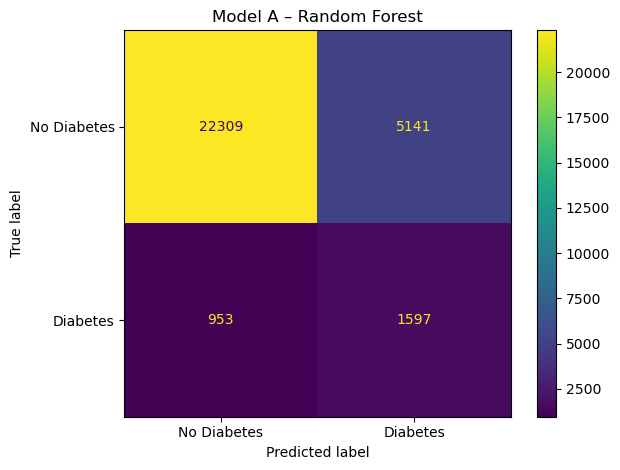

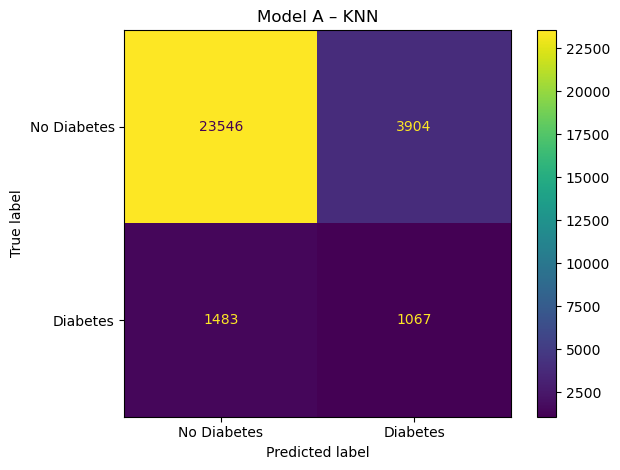

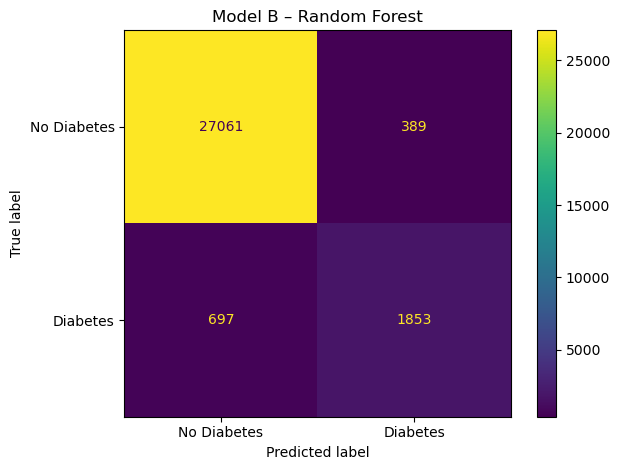

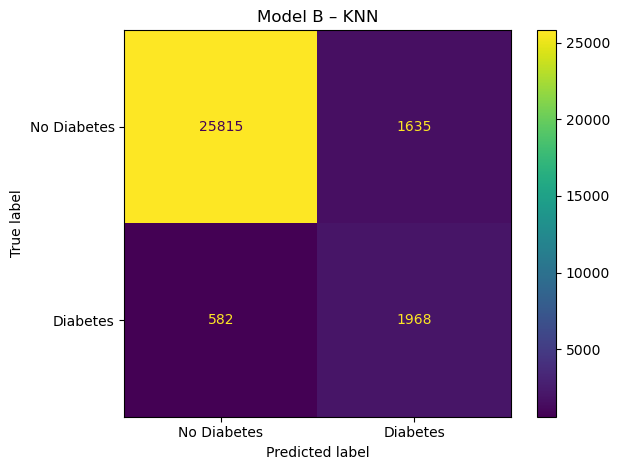

In [13]:
for model_label, feature_list in [
    ("Model A", model_a_features),
    ("Model B", model_b_features),
]:
    for algorithm in ["Random Forest", "KNN"]:
        search = searches[(model_label, algorithm)]
        X_test = df.loc[test_idx, feature_list]
        y_test = y.loc[test_idx]
        y_pred = search.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["No Diabetes", "Diabetes"]
        )
        disp.plot()
        plt.title(f"{model_label} – {algorithm}")
        plt.tight_layout()
        plt.show()


Specificity is included because it measures how well the model correctly identifies
non-diabetic cases:

**Specificity = TN / (TN + FP)**

This is especially useful for interpreting Model A if removal of laboratory features causes
a large increase in false positives.


## 10. Save the Best Pipeline for Each Feature Set


In [14]:
# Select the best algorithm within each feature set using TEST Macro F1 only for
# deployment comparison after the four pre-specified experiments are completed.
# The hyperparameters themselves were selected using CV on the training data.

best_model_a_row = (
    results_df[results_df["Feature Set"] == "Model A"]
    .sort_values("Macro F1", ascending=False)
    .iloc[0]
)

best_model_b_row = (
    results_df[results_df["Feature Set"] == "Model B"]
    .sort_values("Macro F1", ascending=False)
    .iloc[0]
)

best_model_a_algorithm = best_model_a_row["Algorithm"]
best_model_b_algorithm = best_model_b_row["Algorithm"]

joblib.dump(
    searches[("Model A", best_model_a_algorithm)].best_estimator_,
    "models/model_a_pipeline.pkl"
)

joblib.dump(
    searches[("Model B", best_model_b_algorithm)].best_estimator_,
    "models/model_b_pipeline.pkl"
)

print("Saved Model A pipeline:", best_model_a_algorithm)
print("Saved Model B pipeline:", best_model_b_algorithm)


Saved Model A pipeline: Random Forest
Saved Model B pipeline: Random Forest
